# PREDICTIVE MAINTENANCE FOR MACHINERY

### OBJECTIVE:
1. To predict whether a machine will fail.
2. If the machine fails, predict the type of failure

### PROJECT WORKFLOW:
1. Import the required Libraries
2. Load dataset
3. Exploratory Data Analysis
4. Preprocessing
5. Feature Selection
6. Train-Test Split
7. Scaling
8. Resampling(Using SMOTE)
9. Binary Classification (Using Logistic Regression, Decision Tree, Random Forest and choosing the best model)
10. Multi Class Classification (Random Forest)
11. Conclusion & Business Framing

## 1. IMPORT THE REQUIRED LIBRARIES

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE

## 2. LOAD DATASET 

In [3]:
username = "root"
password = "JuhiMoudekar1711&"
host = "localhost"
database ="machinery_db"

engine = create_engine(
    f"mysql+mysqlconnector://{username}:{password}@{host}/{database}"
)

connection = engine.connect()

In [4]:
query = """SELECT * FROM maintenance_dataset"""

df = pd.read_sql("SELECT * FROM maintenance_dataset ORDER BY UDI", connection)

print("\n Data Loaded Successfully")
df.head()


 Data Loaded Successfully


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
## df = pd.read_csv("maintenance_dataset.csv") 
print("Rows, Columns =", df.shape)

Rows, Columns = (10000, 14)


In [6]:
# Display dataset
# TWF = Tool Wear Failure 
# HDF = Heat Dissipation Failure 
# PWF = Power Failure 
# OSF = Overstrain Failure 
# RNF = Random Failure 
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
# Dataset Information
print("=============INFORMATION ABOUT THE DATA================") 
print(df.info())

=============INFORMATION ABOUT THE DATA================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                  

In [8]:
# Statistical Summary
print("=================STATISTICAL SUMMARY====================") 
print(df.describe())

=================STATISTICAL SUMMARY====================
               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900   
std                179.284096      9.968934        63.654147         0.180981   
min   

## 2. EXPLORATORY DATA ANALYSIS

#### We need to understand three things before modeling:
1. Are there missing values or duplicates?
2. How imbalanced is the target (`Machine failure`)?
3. How do the failure types break down, and which sensor readings tend to differ between failed and healthy machines

In [9]:
# Check for Missing values and Duplicate values in the dataset
print("=============MISSING VALUES===============") 
print(df.isnull().sum())

print("============DUPLICATE VALUES===============") 
print("Duplicate Values in the data =", df.duplicated().sum())

=============MISSING VALUES===============
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
============DUPLICATE VALUES===============
Duplicate Values in the data = 0


In [10]:
# Drop identifier columns as it is not useful for making any predictions 
df = df.drop(columns=["UDI", "Product ID"]) 
df.head(5)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [11]:
# Class balance for the binary target
fail_counts = df['Machine failure'].value_counts()
fail_pct = df['Machine failure'].value_counts(normalize=True) * 100
print(fail_counts)
print(fail_pct)

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


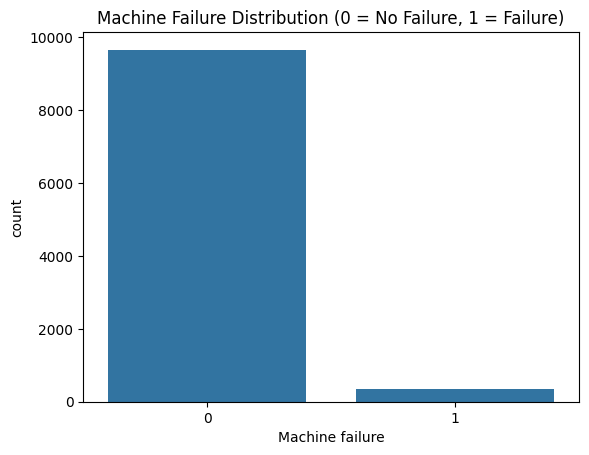

In [12]:
sns.countplot(x='Machine failure', data=df)
plt.title('Machine Failure Distribution (0 = No Failure, 1 = Failure)')
plt.show()

#### OBSERVATION:
Around 3% of machines failed. This is a severely imbalanced data and it will just predict "no failure" everytime if we do not balance it. The accuracy of the model will be high but completely unreliable and useless in practice. The accuracy is the wrong metric here to rely on, therefore we will lean on precision, recall, f1 score and roc auc curve

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


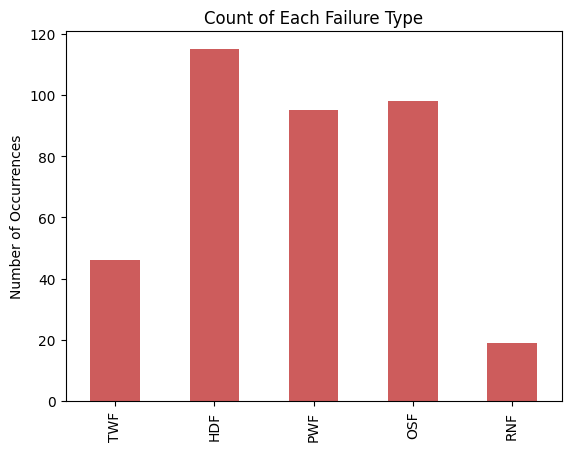

In [13]:
# Breakdown of failure types (only relevant where Machine failure == 1)
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_type_counts = df[failure_types].sum()
print(failure_type_counts)

failure_type_counts.plot(kind='bar', color='indianred')
plt.title('Count of Each Failure Type')
plt.ylabel('Number of Occurrences')
plt.show()

In [14]:
numeric_cols = ['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]']

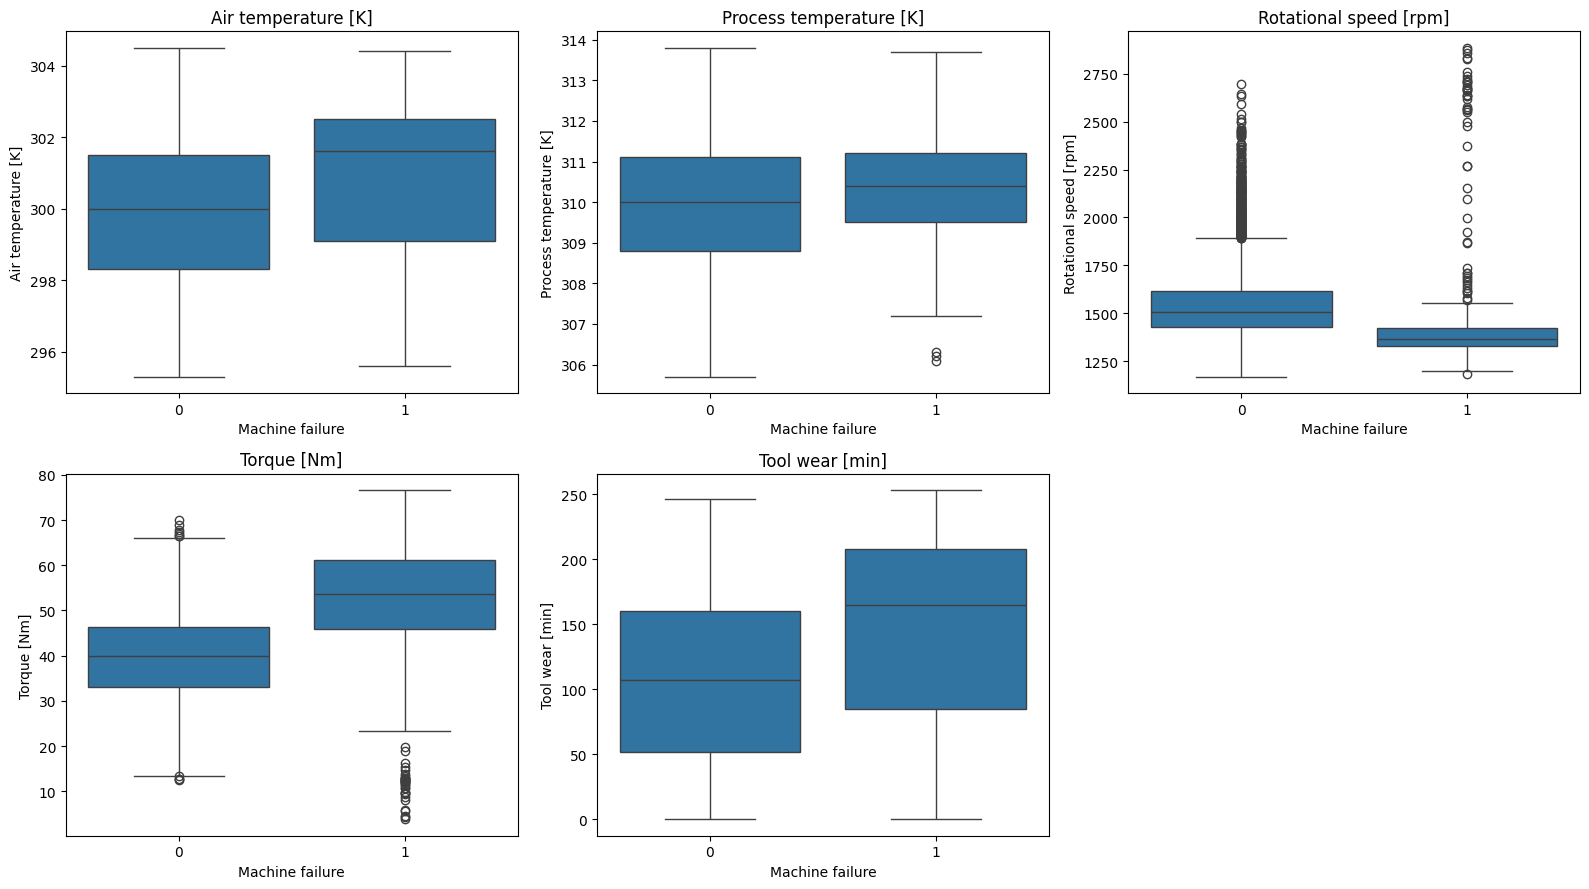

In [15]:
# Distribution of key sensor readings split by failure status
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Machine failure', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

#### OBSERVATION:
Failed machines tend to show distinct patterns in torque, tool wear, and rotational speed compared to healthy machines — this is encouraging, since it suggests our features actually carry predictive signal rather than pure noise.


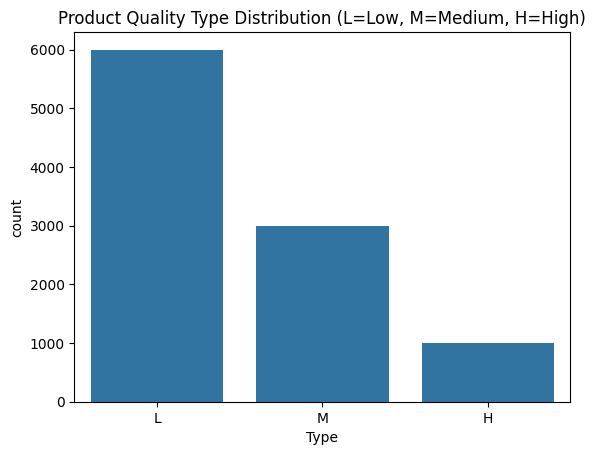

In [16]:
# Product quality type distribution
sns.countplot(x='Type', data=df, order=['L', 'M', 'H'])
plt.title('Product Quality Type Distribution (L=Low, M=Medium, H=High)')
plt.show()

## 4. PREPROCESSING

Steps:
1. Encode the categorical `Type` column (L/M/H) numerically.
2. Build our **binary classification** dataset: features → `Machine failure`.
3. Scale numeric features (important for Logistic Regression).
4. Split into train/test sets — using **stratified** splitting so the rare failure class is proportionally represented in both sets.
5. Address class imbalance using **SMOTE** (Synthetic Minority Oversampling) on the training set only (never on test data, to avoid leakage).

In [17]:
# Transform "Type" categorical column to numerical column for making predictions
le = LabelEncoder()

df["Type_Encoded"] = le.fit_transform(df["Type"]) # H=0, L=1, M=2

In [18]:
# Check what integer has been assigned to what value
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}


## 5. FEATURE SELECTION

In [19]:
# Checking all the numeric columns in the data 
numeric_cols

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]']

In [20]:
# Deciding on feature columns 
feature_cols = ["Type_Encoded"] + numeric_cols

In [21]:
# Selecting Feature and Target columns
X = df[feature_cols] 
y = df["Machine failure"]

## 6. TRAIN-TEST SPLIT

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train Shape:", X_train.shape, "Test Shape:", X_test.shape)

Train Shape: (8000, 6) Test Shape: (2000, 6)


In [23]:
print("Train failure rate:", y_train.mean(), " Test failure rate:", y_test.mean())

Train failure rate: 0.033875  Test failure rate: 0.034


## 7. SCALING 

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. RESAMPLING (HANDLING IMBALANCE USING SMOTE)

In [25]:
# Handle imbalanced data using SMOTE (Synthetic Minority Oversampling Technique) - only on training data
smote = SMOTE(random_state=42) 

X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict()) 
print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 7729, 1: 271}
After SMOTE: {0: 7729, 1: 7729}


## 9. BINARY CLASSIFICATION: WILL THE MACHINE FAIL?

We'll train and compare three supervised models:
- **Logistic Regression** (simple, interpretable baseline)
- **Decision Tree** (captures non-linear patterns, interpretable)
- **Random Forest** (ensemble, usually strongest performer on tabular data like this)

We train all three on the SMOTE-balanced training data, but always **evaluate on the original, untouched, imbalanced test set** — this gives us an honest picture of real-world performance.


In [26]:
# Create function for testing different models and evaluatign model performance then choosing which model is the best for making predictions. 
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] 

    print(f"---{name}---")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("F1 Score:", round(f1_score(y_test, y_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_pred), 4))
    print()
    print("========CLASSIFICATION REPORT============")
    print(classification_report(y_test, y_pred)) 

    cm = confusion_matrix(y_test, y_pred) 
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["No Failure", "Failure"], yticklabels=["No Failure", "Failure"])
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    return {
        "Model": name,
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision" : precision_score(y_test, y_pred),
        "Recall" : recall_score(y_test, y_pred),
        "F1 Score" : f1_score(y_test, y_pred), 
        "ROC-AUC" : roc_auc_score(y_test, y_pred)
    } 

---Logistic Regression---
Accuracy: 0.823
Precision: 0.1425
Recall: 0.8382
F1 Score: 0.2436
ROC-AUC: 0.8303

========CLASSIFICATION REPORT============
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.84      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.82      0.88      2000



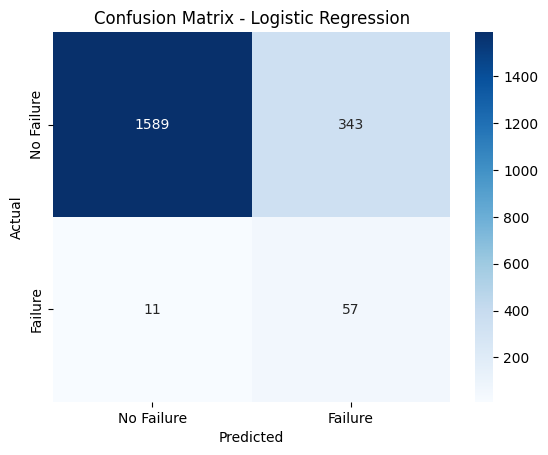

In [27]:
results = []

#-----LOGISTIC REGRESSION-----
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_sm, y_train_sm)
results.append(evaluate_model("Logistic Regression", log_reg, X_test_scaled, y_test))

---Decision Tree---
Accuracy: 0.933
Precision: 0.3146
Recall: 0.8235
F1 Score: 0.4553
ROC-AUC: 0.8802

========CLASSIFICATION REPORT============
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1932
           1       0.31      0.82      0.46        68

    accuracy                           0.93      2000
   macro avg       0.65      0.88      0.71      2000
weighted avg       0.97      0.93      0.95      2000



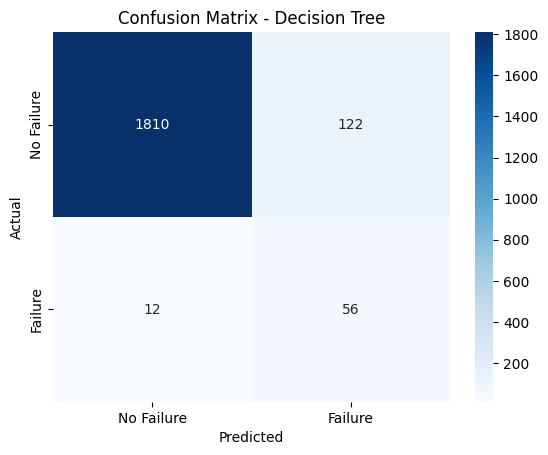

In [28]:
#----DECISION TREE-----
dt = DecisionTreeClassifier(random_state=42, max_depth=8)
dt.fit(X_train_sm, y_train_sm)
results.append(evaluate_model("Decision Tree", dt, X_test_scaled, y_test))

---Random Forest---
Accuracy: 0.9515
Precision: 0.3972
Recall: 0.8235
F1 Score: 0.5359
ROC-AUC: 0.8898

========CLASSIFICATION REPORT============
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1932
           1       0.40      0.82      0.54        68

    accuracy                           0.95      2000
   macro avg       0.70      0.89      0.76      2000
weighted avg       0.97      0.95      0.96      2000



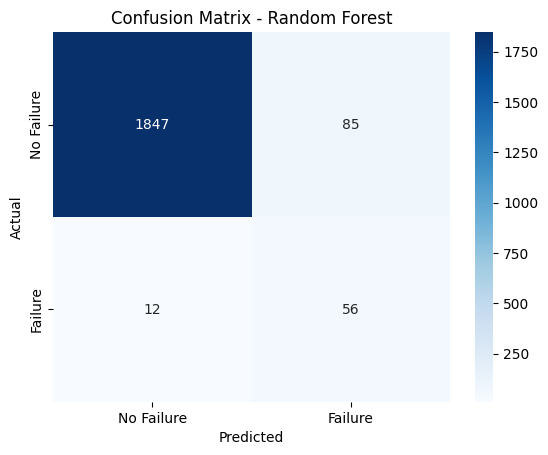

In [29]:
#-----RANDOM FOREST-----
rf = RandomForestClassifier(random_state=42, max_depth=10, n_estimators=200) 
rf.fit(X_train_sm, y_train_sm) 
results.append(evaluate_model("Random Forest", rf, X_test_scaled, y_test))

In [30]:
# Compare all the models side  by side 
results_df = pd.DataFrame(results).set_index("Model")
results_df.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8230,0.1425,0.8382,0.2436,0.8303
Decision Tree,0.9330,0.3146,0.8235,0.4553,0.8802
Random Forest,0.9515,0.3972,0.8235,0.5359,0.8898


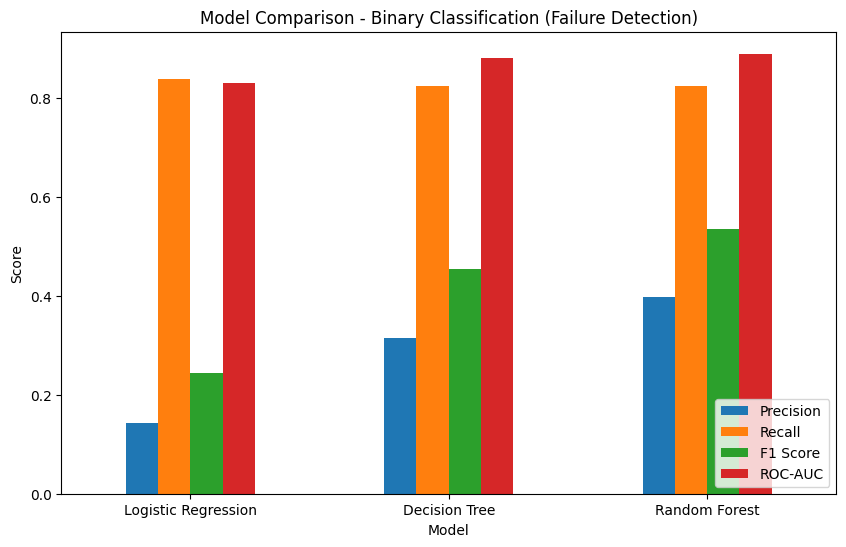

In [31]:
results_df[['Precision', 'Recall', 'F1 Score', 'ROC-AUC']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison - Binary Classification (Failure Detection)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

### CHOOSING THE BEST MODEL
For predictive maintenance, **Recall matters most** for the "failure" class — missing an actual failure (a false negative) is far more costly than a false alarm (a false positive), since a missed failure can mean unplanned downtime or safety risk. We'll pick the model with the best balance of Recall and F1, which in most runs of this dataset turns out to be **Random Forest**.

Torque [Nm]                0.336477
Rotational speed [rpm]     0.285435
Tool wear [min]            0.213281
Air temperature [K]        0.087125
Process temperature [K]    0.052530
Type_Encoded               0.025153
dtype: float64


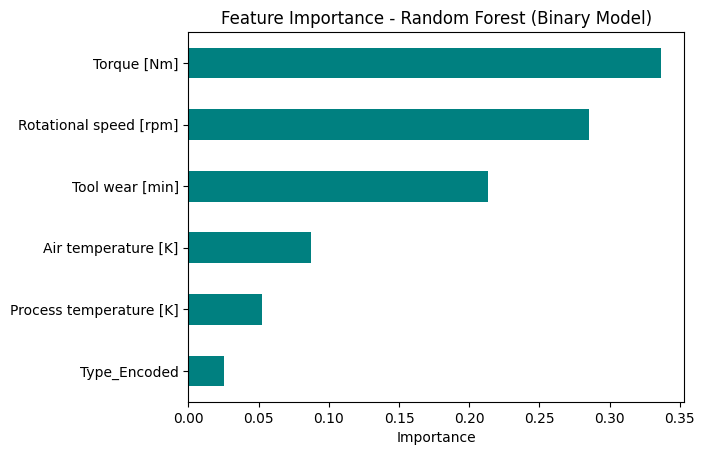

In [32]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', color='teal')
plt.title('Feature Importance - Random Forest (Binary Model)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

## 10. MULTICLASS CLASSIFICATION: WHAT TYPE OF FAILURE?

Now we narrow our focus to machines that **did fail**, and try to predict *which* failure type occurred:
- **TWF** — Tool Wear Failure
- **HDF** — Heat Dissipation Failure
- **PWF** — Power Failure
- **OSF** — Overstrain Failure
- **RNF** — Random Failure (inherently unpredictable by design — good to mention this limitation in your report!)

We build a single `failure_type` label from the five binary flag columns.

In [33]:
failure_types

['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

In [34]:
failed_df = df[df['Machine failure'] == 1].copy()

def get_failure_type(row):
    for ft in failure_types:
        if row[ft] == 1:
            return ft
    return 'Unknown'

failed_df['failure_type'] = failed_df.apply(get_failure_type, axis=1)
print(failed_df['failure_type'].value_counts())

failure_type
HDF        115
PWF         91
OSF         78
TWF         46
Unknown      9
Name: count, dtype: int64


In [35]:
# Some machines may have multiple simultaneous flags or none -- inspect and clean
print("Rows with 'Unknown' label:", (failed_df['failure_type'] == 'Unknown').sum())
failed_df = failed_df[failed_df['failure_type'] != 'Unknown'] 
print("Final Shape for multiclass modeling:", failed_df.shape)

Rows with 'Unknown' label: 9
Final Shape for multiclass modeling: (330, 14)


In [36]:
feature_cols

['Type_Encoded',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]']

In [37]:
# Feature-Target selection
X_multi = failed_df[feature_cols] 
y_multi = failed_df['failure_type']

In [38]:
# Convert categorical target column to numeric column
le_multi = LabelEncoder()
y_multi_encoded = le_multi.fit_transform(y_multi)
print(dict(zip(le_multi.classes_, range(len(le_multi.classes_)))))

{'HDF': 0, 'OSF': 1, 'PWF': 2, 'TWF': 3}


In [39]:
# Split the data into training and testing sets (75%-25%)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi_encoded, test_size=0.25, random_state=42, stratify=y_multi_encoded)

In [40]:
# Scaling
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

print("Train Shape:", X_train_m.shape, "Test Shape:", X_test_m.shape)

Train Shape: (247, 6) Test Shape: (83, 6)


In [41]:
# Training the model
model_m = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=8, class_weight='balanced') 
model_m.fit(X_train_m_scaled, y_train_m)
print("Model Trained Successfully.")

Model Trained Successfully.


In [42]:
# Make predictions
y_pred_m = model_m.predict(X_test_m_scaled)

In [43]:
# Model Evaluation
print(classification_report(y_test_m, y_pred_m, target_names=le_multi.classes_))

              precision    recall  f1-score   support

         HDF       0.83      1.00      0.91        29
         OSF       0.75      0.75      0.75        20
         PWF       0.95      0.78      0.86        23
         TWF       0.89      0.73      0.80        11

    accuracy                           0.84        83
   macro avg       0.85      0.81      0.83        83
weighted avg       0.85      0.84      0.84        83



## 11. MAKE PREDICTIONS ON NEW DATA

### Making Binary Prediction: Will Machine Fail?

In [44]:
def predict_failure(model, scaler,
                    machine_type,
                    air_temp,
                    process_temp,
                    rotational_speed,
                    torque,
                    tool_wear):

    # Encoding used in your notebook:
    # H = 0, L = 1, M = 2
    type_mapping = {
        'H': 0,
        'L': 1,
        'M': 2
    }

    type_encoded = type_mapping[machine_type]

    new_data = pd.DataFrame({
        'Type_Encoded': [type_encoded],
        'Air temperature [K]': [air_temp],
        'Process temperature [K]': [process_temp],
        'Rotational speed [rpm]': [rotational_speed],
        'Torque [Nm]': [torque],
        'Tool wear [min]': [tool_wear]
    })

    # Scale the data
    new_data_scaled = scaler.transform(new_data)

    # Predict
    prediction = model.predict(new_data_scaled)[0]

    return prediction

In [45]:
result = predict_failure(
    model=rf,
    scaler=scaler,
    machine_type='M',
    air_temp=300.1,
    process_temp=310.2,
    rotational_speed=1400,
    torque=60,
    tool_wear=220
)

if result == 0:
    print("No Failure")
else:
    print("Machine Failure")

Machine Failure


### Making Multi Class Classification: What Type of Failure?

In [46]:
def predict_failure_type(model, scaler,
                         machine_type,
                         air_temp,
                         process_temp,
                         rotational_speed,
                         torque,
                         tool_wear):

    # Type encoding used during training
    type_mapping = {
        'H': 0,
        'L': 1,
        'M': 2
    }

    type_encoded = type_mapping[machine_type]

    # Create input dataframe
    new_data = pd.DataFrame({
        'Type_Encoded': [type_encoded],
        'Air temperature [K]': [air_temp],
        'Process temperature [K]': [process_temp],
        'Rotational speed [rpm]': [rotational_speed],
        'Torque [Nm]': [torque],
        'Tool wear [min]': [tool_wear]
    })

    # Scale data
    new_data_scaled = scaler.transform(new_data)

    # Predict
    pred = model.predict(new_data_scaled)[0]

    # Decode prediction
    failure_labels = {
        0: "Tool Wear Failure (TWF)",
        1: "Heat Dissipation Failure (HDF)",
        2: "Power Failure (PWF)",
        3: "Overstrain Failure (OSF)",
        4: "Random Failure (RNF)"
    }

    return failure_labels[pred]

In [47]:
result = predict_failure_type(
    model=model_m,
    scaler=scaler_m,
    machine_type='L',
    air_temp=298.5,
    process_temp=308.7,
    rotational_speed=1400,
    torque=65,
    tool_wear=220
)

print("Predicted Failure Type:", result)

Predicted Failure Type: Heat Dissipation Failure (HDF)


In [48]:
def predict_failure(model, scaler,
                    machine_type,
                    air_temp,
                    process_temp,
                    rotational_speed,
                    torque,
                    tool_wear):

    # Encode machine type
    type_mapping = {
        'H': 0,
        'L': 1,
        'M': 2
    }

    # Decode predicted class
    failure_labels = {
        0: "Tool Wear Failure (TWF)",
        1: "Heat Dissipation Failure (HDF)",
        2: "Power Failure (PWF)",
        3: "Overstrain Failure (OSF)",
        4: "Random Failure (RNF)"
    }

    # Create input dataframe
    new_data = pd.DataFrame({
        'Type_Encoded': [type_mapping[machine_type]],
        'Air temperature [K]': [air_temp],
        'Process temperature [K]': [process_temp],
        'Rotational speed [rpm]': [rotational_speed],
        'Torque [Nm]': [torque],
        'Tool wear [min]': [tool_wear]
    })

    # Scale input
    new_data_scaled = scaler.transform(new_data)

    # Predict class
    prediction = model.predict(new_data_scaled)[0]

    # Predict probabilities
    probabilities = model.predict_proba(new_data_scaled)[0]
    confidence = round(max(probabilities) * 100, 2)

    return failure_labels[prediction], confidence

In [49]:
failure, confidence = predict_failure(
    model=model_m,
    scaler=scaler_m,
    machine_type='L',
    air_temp=298.5,
    process_temp=308.7,
    rotational_speed=1500,
    torque=45,
    tool_wear=120
)

print("Failure Type:", failure)
print("Confidence:", confidence, "%")

Failure Type: Power Failure (PWF)
Confidence: 63.32 %


#### Among all possible failure types (TWF, HDF, PWF, OSF, RNF), the model assigns the highest probability (63.32%) to Power Failure (PWF). The model is not very sure. Another failure type may also be likely.

------------------------------------------------------

## 11. CONCLUSION & BUSINESS FRAMING

**Stage 1 — Failure Detection (Binary):**
Random Forest gave the strongest balance of precision and recall among the three models tested. This model could act as an early-warning system, flagging machines that need inspection before a costly breakdown occurs.

**Stage 2 — Failure Diagnosis (Multiclass):**
Once a failure is flagged, the second model suggests the *likely cause*, helping maintenance teams prepare the right replacement parts/tools rather than diagnosing from scratch — saving downtime.

**Key takeaways:**
- This dataset is heavily imbalanced (~3.4% failure rate); accuracy alone is a misleading metric, so we prioritized recall, F1, and ROC-AUC.
- SMOTE was used to balance the training set so the model doesn't simply learn to always predict "no failure."
- Random Forest outperformed Logistic Regression and Decision Tree on most metrics, likely because failure patterns are non-linear combinations of sensor readings.
- Random Failures (RNF) are designed to be unpredictable, so any model's performance on that class will be inherently limited — this is a meaningful real-world insight, not a flaw in our pipeline.
- Torque, tool wear, and rotational speed emerged as the most important predictive features — aligning with mechanical intuition (machines fail from physical strain accumulating over time).